# Entrega 1 — Análise Descritiva dos Dados da CTI
**Nome:** Luiz Henrique Zaim da Cruz, Lucio Vecchio, Gustavo Pires, Eric Aloise

**Disciplina:** Análise Inferencial de Dados  
**Projeto:** Plataforma Analítica de Planejamento Financeiro  
**Base:** Demonstrativo Fecap v3.csv

O objetivo desta entrega é conhecer a distribuição e a variação dos dados antes de fazer a análise de regressão da próxima entrega. Para isso, apresentamos média, mediana, moda, variância, desvio padrão, histogramas e boxplots. Cada resultado foi calculado separadamente para a conta financeira e o ano correspondentes.

O arquivo original é mantido sem alterações. A unidade monetária não está especificada no CSV; quando os resultados são apresentados em bilhões, isso significa apenas que dividimos o valor original por 1.000.000.000.

## 1. Leitura da base

No Colab, execute a célula seguinte e selecione o CSV quando o upload aparecer. A primeira linha do arquivo já é um registro, e os valores usam ponto para milhar e vírgula para decimal. Por esse motivo, primeiro lemos todas as colunas como texto.

In [1]:
import os
from pathlib import Path
import pandas as pd

arquivo = Path(os.environ.get('CAMINHO_CSV', 'Demonstrativo Fecap v3.csv'))
if not arquivo.is_file():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError('Coloque o CSV na pasta do notebook ou defina CAMINHO_CSV.') from exc
    enviados = files.upload()
    if not enviados:
        raise FileNotFoundError('Nenhum CSV foi enviado.')
    arquivo = Path(next(iter(enviados)))

# O CSV não tem cabeçalho: a primeira linha já é um registro.
# O texto usa ponto de milhar e vírgula decimal; primeiro lemos como texto.
colunas = ['ano', 'cenario', 'conta', 'valor_br']
dados_brutos = pd.read_csv(
    arquivo, sep=';', encoding='cp1252', header=None,
    names=colunas, dtype=str, keep_default_na=False
)
print(f'Arquivo: {arquivo.name}')
print(f'Linhas: {len(dados_brutos):,} | Colunas: {len(dados_brutos.columns)}')
# As linhas da base não são exibidas: o repositório é público e a base é confidencial

Saving Demonstrativo Fecap v3.csv to Demonstrativo Fecap v3.csv
Arquivo: Demonstrativo Fecap v3.csv
Linhas: 1,002,000 | Colunas: 4


## 2. Estrutura e qualidade dos dados

Cada linha apresenta o ano do demonstrativo, um cenário, o nome de uma conta e seu valor. Os períodos são chamados de Ano 1 a Ano 12; o CSV não informa a correspondência com anos do calendário. As siglas BAL, DRE e FLU fazem parte dos nomes das contas.

In [2]:
dados = dados_brutos.copy()
dados['ano_num'] = pd.to_numeric(
    dados['ano'].str.extract(r'(\d+)', expand=False), errors='coerce'
).astype('Int64')
dados['valor'] = pd.to_numeric(
    dados['valor_br'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
    errors='coerce'
)

sem_conta = dados['conta'].eq('')
contas_identificadas = dados.loc[~sem_conta]
diagnostico = pd.Series({
    'linhas': len(dados),
    'anos': dados['ano'].nunique(),
    'cenários': dados['cenario'].nunique(),
    'contas com nome': contas_identificadas['conta'].nunique(),
    'linhas sem nome da conta': int(sem_conta.sum()),
    'valores sem conversão numérica': int(dados['valor'].isna().sum()),
    'repetições de ano/cenário/conta com nome': int(
        contas_identificadas.duplicated(['ano', 'cenario', 'conta']).sum()
    ),
})
display(diagnostico.to_frame('quantidade'))

resumo_anual = (
    dados.groupby('ano_num', sort=True, observed=True)
    .agg(linhas=('valor', 'size'), cenarios=('cenario', 'nunique'))
)
resumo_anual['contas_com_nome'] = (
    contas_identificadas.groupby('ano_num', observed=True)['conta'].nunique()
)
resumo_anual['linhas_sem_conta'] = dados.loc[sem_conta].groupby(
    'ano_num', observed=True
).size()
display(resumo_anual)

,quantidade
linhas,1002000
anos,12
cenários,1200
contas com nome,69
linhas sem nome da conta,43200
valores sem conversão numérica,0
repetições de ano/cenário/conta com nome,0


,linhas,cenarios,contas_com_nome,linhas_sem_conta
ano_num,,,,
1,85200,1200,68,3600
2,85200,1200,68,3600
3,86400,1200,69,3600
4,86400,1200,69,3600
5,86400,1200,69,3600
6,86400,1200,69,3600
7,86400,1200,69,3600
8,86400,1200,69,3600
9,86400,1200,69,3600


O diagnóstico mostra 1.002.000 linhas, 12 anos, 1.200 cenários e 69 contas financeiras com nome. Todos os valores numéricos puderam ser convertidos. Existem 43.200 linhas sem nome de conta, três para cada combinação de ano e cenário. Entre as contas com nome, não há repetição da mesma conta dentro de uma combinação de ano e cenário. No Ano 12, o número de contas com nome é menor.

## 3. Seleção dos dados para a análise

As linhas sem nome de conta não podem ser atribuídas com segurança a um indicador financeiro. Por isso, elas ficam fora dos cálculos por conta, mas continuam no arquivo original. Também manteremos os valores negativos e os valores extremos, pois podem fazer parte dos cenários. A distribuição será examinada para cada conta e ano.

Calculamos as estatísticas de **todas as 69 contas identificadas** nos anos em que aparecem. Para discutir os gráficos com mais clareza, selecionamos quatro contas presentes nos 12 períodos: Receita, Custos, Resultado Líquido e Total do Ativo.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

dados_analise = dados.loc[dados['conta'].ne('') & dados['valor'].notna()].copy()
dados_analise['valor_bilhoes'] = dados_analise['valor'] / 1_000_000_000

contas_foco = [
    'DRE - Receita',
    'DRE - Custos',
    'DRE - Resultado Líquido',
    'BAL - Total do Ativo',
]
dados_foco = dados_analise[dados_analise['conta'].isin(contas_foco)].copy()
disponibilidade = dados_foco.pivot_table(
    index='conta', columns='ano_num', values='valor', aggfunc='count'
).reindex(contas_foco)
display(disponibilidade)
assert disponibilidade.notna().all().all(), 'Uma das contas não está presente em todos os anos.'

ano_num,1,2,3,4,5,6,7,8,9,10,11,12
conta,,,,,,,,,,,,
DRE - Receita,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200
DRE - Custos,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200
DRE - Resultado Líquido,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200
BAL - Total do Ativo,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200,1200


## 4. Medidas de posição e dispersão

A média, a mediana e a moda descrevem valores centrais. A variância e o desvio padrão mostram o espalhamento dos resultados entre cenários de um mesmo ano. Usamos a variância **populacional** (`ddof=0`), porque descrevemos todos os 1.200 cenários presentes no arquivo para cada conta e período. A variância é expressa em bilhões ao quadrado, e o desvio padrão em bilhões.

A moda é o valor exato mais frequente. Se todos os valores forem diferentes, indicamos que não há moda; se houver empate, registramos as modas empatadas. A contagem de valores extremos usa a regra do boxplot: valores abaixo de Q1 − 1,5 × AIQ ou acima de Q3 + 1,5 × AIQ. Essa marcação é descritiva e não significa que os dados devam ser apagados.

In [4]:
linhas_resumo = []
for (conta, ano), grupo in dados_analise.groupby(['conta', 'ano_num'], sort=True):
    serie = grupo['valor_bilhoes']
    frequencias = grupo['valor_br'].value_counts()
    maior_frequencia = int(frequencias.iloc[0])
    modas_br = frequencias[frequencias.eq(maior_frequencia)].index.tolist()
    if maior_frequencia == 1:
        moda = 'sem moda'
    elif len(modas_br) > 3:
        moda = f'{len(modas_br)} modas empatadas'
    else:
        moda = ' / '.join(f'{float(v.replace(".", "").replace(",", "."))/1e9:.6f}' for v in modas_br)
    q1, q3 = serie.quantile([0.25, 0.75])
    amplitude_interquartil = q3 - q1
    extremos = ((serie < q1 - 1.5 * amplitude_interquartil) |
                (serie > q3 + 1.5 * amplitude_interquartil)).sum()
    linhas_resumo.append({
        'conta': conta, 'ano': int(ano), 'n': len(serie),
        'media_bi': serie.mean(), 'mediana_bi': serie.median(),
        'moda_bi': moda, 'frequencia_moda': maior_frequencia,
        'variancia_bi2': serie.var(ddof=0),
        'desvio_padrao_bi': serie.std(ddof=0),
        'minimo_bi': serie.min(), 'maximo_bi': serie.max(),
        'q1_bi': q1, 'q3_bi': q3, 'extremos_boxplot': int(extremos),
    })

estatisticas = pd.DataFrame(linhas_resumo)
estatisticas_foco = estatisticas[estatisticas['conta'].isin(contas_foco)].copy()
print(f'Grupos de conta e ano analisados: {len(estatisticas)}')
print('Tabela completa de todas as contas: variável estatisticas')
display(estatisticas_foco[[
    'conta', 'ano', 'n', 'media_bi', 'mediana_bi', 'moda_bi',
    'frequencia_moda', 'variancia_bi2', 'desvio_padrao_bi',
    'extremos_boxplot'
]].round(5).sort_values(['conta', 'ano']).reset_index(drop=True))

Grupos de conta e ano analisados: 799
Tabela completa de todas as contas: variável estatisticas


,conta,ano,n,media_bi,mediana_bi,moda_bi,frequencia_moda,variancia_bi2,desvio_padrao_bi,extremos_boxplot
0,BAL - Total do Ativo,1,1200,10.60359,10.61576,10.504259,96,0.00205,0.04529,170
1,BAL - Total do Ativo,2,1200,10.29240,10.32136,10.067437,96,0.01009,0.10043,179
2,BAL - Total do Ativo,3,1200,10.73705,10.78432,10.413816,96,0.02297,0.15155,185
3,BAL - Total do Ativo,4,1200,9.57125,9.61237,9.228846,96,0.01901,0.13788,177
4,BAL - Total do Ativo,5,1200,8.08608,8.06395,8.291330,96,0.01149,0.10717,193
5,BAL - Total do Ativo,6,1200,7.54762,7.52275,7.738008,96,0.01473,0.12138,195
6,BAL - Total do Ativo,7,1200,7.19838,7.18141,7.181408,96,0.01982,0.14080,42
7,BAL - Total do Ativo,8,1200,7.47859,7.50215,7.110350,96,0.07617,0.27599,190
8,BAL - Total do Ativo,9,1200,7.23227,7.30516,6.439615,96,0.20366,0.45129,193
9,BAL - Total do Ativo,10,1200,6.46350,6.55640,5.364261,96,0.36020,0.60016,191


## 5. Histogramas

Os histogramas mostram como os 1.200 cenários se distribuem em cada conta. Apresentamos o primeiro e o último ano para visualizar a diferença entre as distribuições sem juntar períodos com valores muito diferentes. Os gráficos são feitos com os dados completos, sem retirar valores extremos.

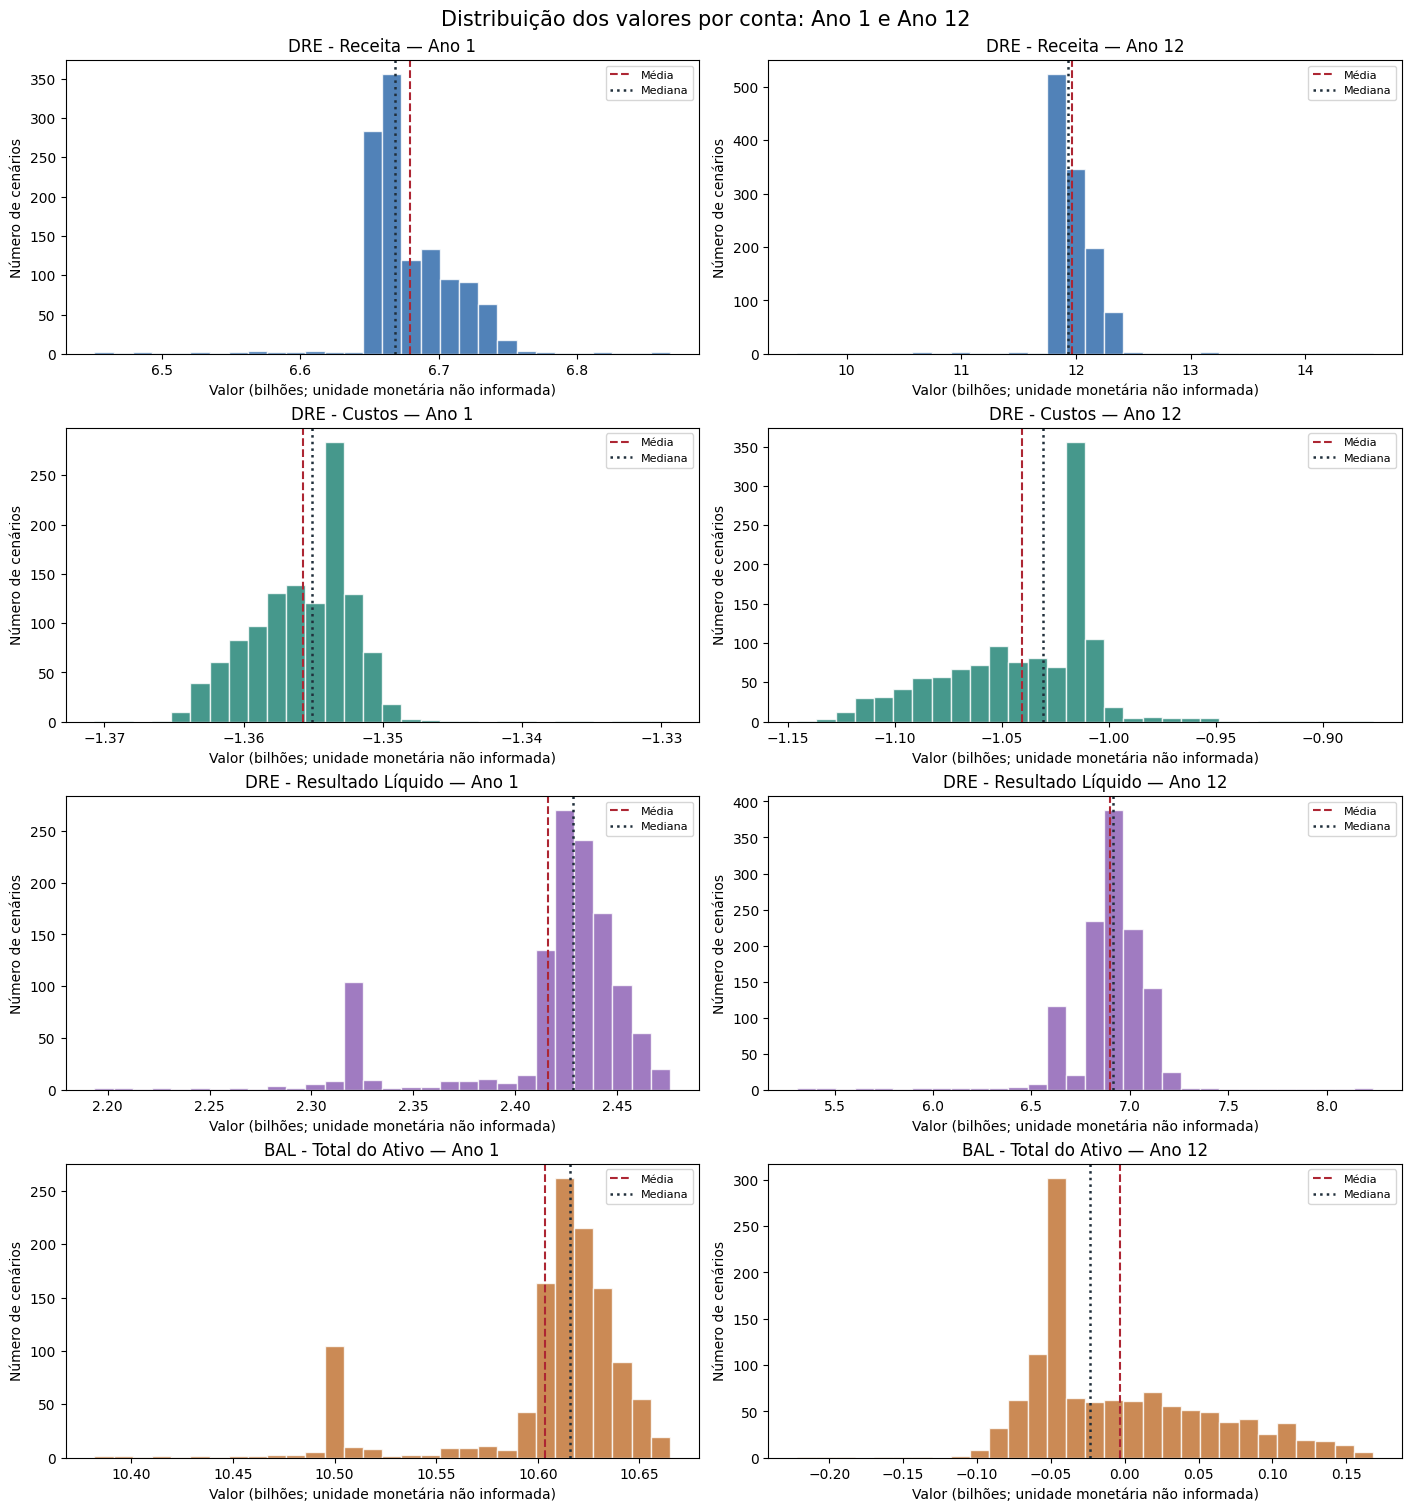

In [5]:
fig, eixos = plt.subplots(4, 2, figsize=(14, 15), constrained_layout=True)
cores = ['#2563a6', '#187f70', '#895ab2', '#be6d2b']
for i, conta in enumerate(contas_foco):
    for j, ano in enumerate([1, 12]):
        ax = eixos[i, j]
        valores = dados_foco.loc[
            (dados_foco['conta'] == conta) & (dados_foco['ano_num'] == ano),
            'valor_bilhoes'
        ]
        ax.hist(valores, bins=30, color=cores[i], alpha=0.8, edgecolor='white')
        ax.axvline(valores.mean(), color='#ad2633', linestyle='--',
                   linewidth=1.5, label='Média')
        ax.axvline(valores.median(), color='#202f3b', linestyle=':',
                   linewidth=1.8, label='Mediana')
        ax.set_title(f'{conta} — Ano {ano}')
        ax.set_xlabel('Valor (bilhões; unidade monetária não informada)')
        ax.set_ylabel('Número de cenários')
        ax.legend(fontsize=8)
fig.suptitle('Distribuição dos valores por conta: Ano 1 e Ano 12', fontsize=15)
plt.show()

## 6. Boxplots

Cada caixa representa a distribuição dos 1.200 cenários de um ano: a linha central é a mediana, a caixa vai do primeiro ao terceiro quartil e os pontos isolados seguem o critério de 1,5 vez a amplitude interquartil. As escalas mudam entre contas, por isso cada gráfico deve ser lido separadamente.

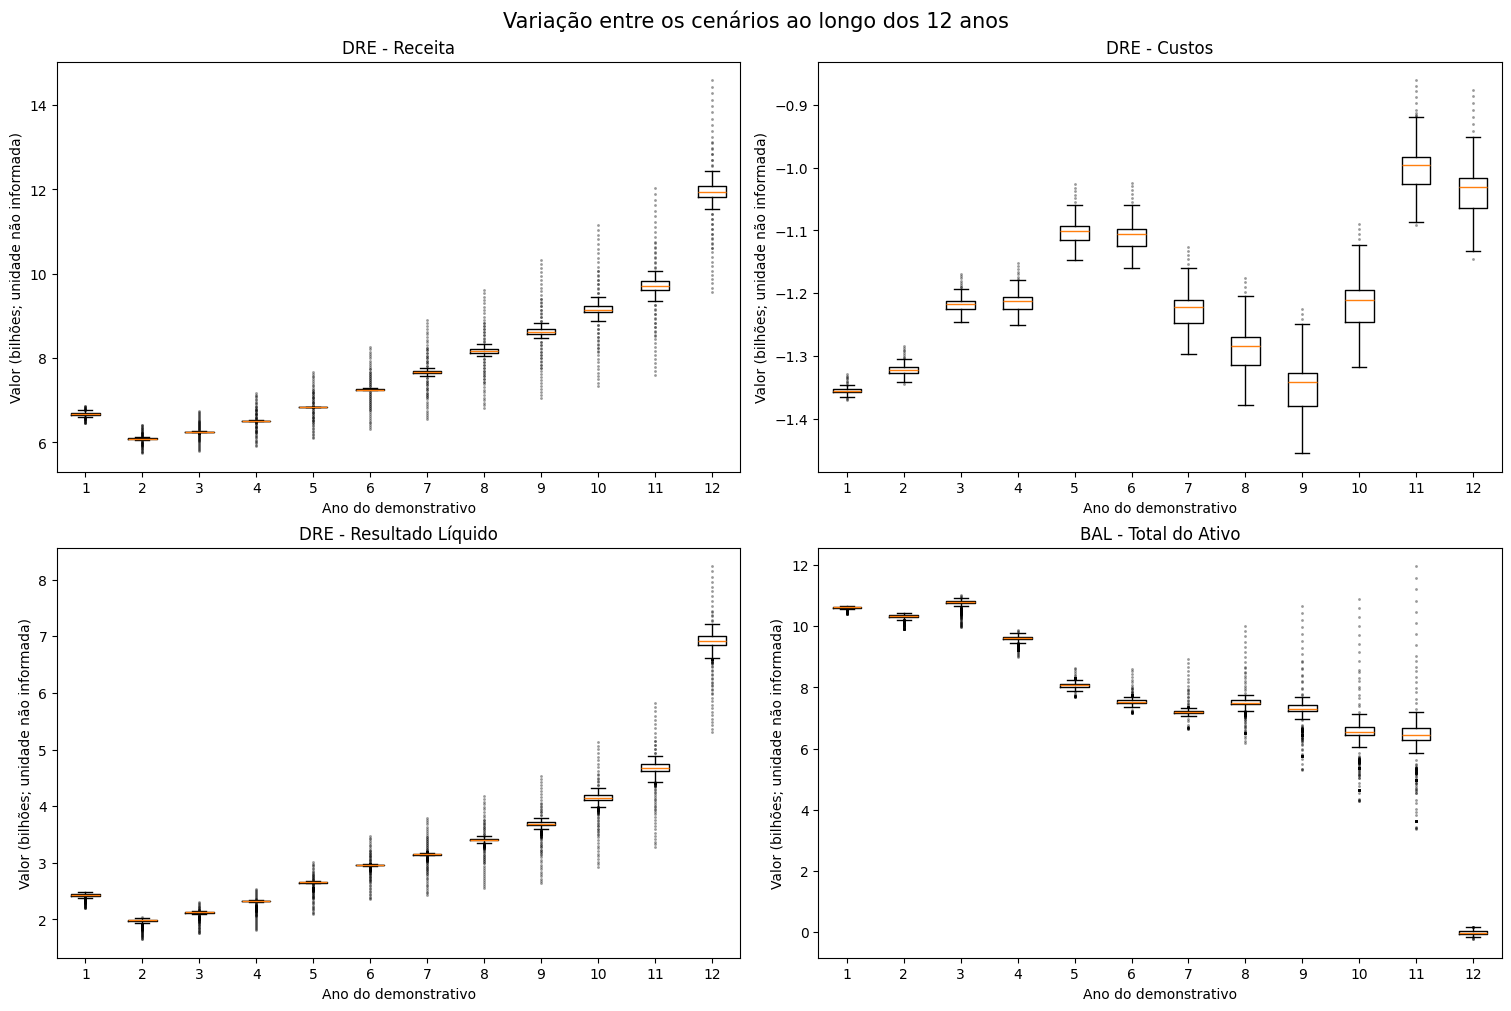

In [6]:
fig, eixos = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
for i, (ax, conta) in enumerate(zip(eixos.ravel(), contas_foco)):
    grupos_ano = [
        dados_foco.loc[
            (dados_foco['conta'] == conta) & (dados_foco['ano_num'] == ano),
            'valor_bilhoes'
        ].to_numpy()
        for ano in range(1, 13)
    ]
    ax.boxplot(grupos_ano, tick_labels=[str(ano) for ano in range(1, 13)],
               flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.4})
    ax.set_title(conta)
    ax.set_xlabel('Ano do demonstrativo')
    ax.set_ylabel('Valor (bilhões; unidade não informada)')
fig.suptitle('Variação entre os cenários ao longo dos 12 anos', fontsize=15)
plt.show()

## 7. Interpretação dos resultados

Ao comparar os cenários do Ano 1 e do Ano 12, a média de **DRE - Receita** passa de aproximadamente **6,679 bilhões para 11,962 bilhões**. O desvio padrão também aumenta, de **0,035 para 0,330 bilhão**. Portanto, a receita do último período é maior e apresenta mais variação entre cenários.

A média do **Resultado Líquido** passa de cerca de **2,416 para 6,900 bilhões**. Em **DRE - Custos**, os números são negativos na forma registrada pela base: a média muda de aproximadamente **−1,356 para −1,041 bilhão**. Por causa desse sinal, a leitura dos custos precisa respeitar a convenção do demonstrativo.

O **Total do Ativo** merece uma verificação específica: sua média passa de aproximadamente **10,604 bilhões no Ano 1** para um valor muito próximo de **zero no Ano 12**, e há cenários com valores negativos nesse último período. Os números foram mantidos como estão no arquivo. A CTI informou que o Ano 12 corresponde ao encerramento da concessão, o que ajuda a entender a mudança de nível; ainda assim, antes de dar uma explicação financeira para essa conta, é necessário confirmar com a CTI como ela foi calculada nesse ano.

As modas da tabela mostram que vários cenários repetem exatamente o mesmo valor. Em todas as contas e anos da tabela, o grupo da moda inclui os mesmos 94 cenários, todos com identificador entre Cen_01001 e Cen_01200, que têm trajetória idêntica nos 12 anos, conforme identificado na preparação dos dados do projeto. Por isso, aqui a moda não representa um valor típico da distribuição: ela revela esse bloco de cenários repetidos, que também aparece como uma barra isolada em alguns histogramas. Os boxplots indicam observações fora da faixa de 1,5 vez a amplitude interquartil em algumas contas e períodos. São pontos para investigar, não erros comprovados.

## 8. Conclusão
A análise descritiva mostra mudanças de nível e de dispersão nas contas financeiras ao longo dos 12 anos. A base tem valores numéricos completos para as contas nomeadas, mas também contém linhas sem identificação e diferenças no número de contas registradas no Ano 12. Por isso, as comparações foram feitas apenas entre contas identificadas e separadamente por período.


**Fonte:** Demonstrativo Fecap v3.csv, base disponibilizada para o projeto CTI.